# e25 Norway Hybrid Sampling Analysis

Analysis of experiment `e25TR_norway_hybrid_sampling`, which trains TAGConv (100 epochs) and SparseGT (1 epoch)
on **hybrid-sampled** datasets across resolutions 1–20.

Hybrid sampling uses a mix of uniform and biased source/target selection:
- **Sources**: 50% uniform, 50% biased toward high elevation gradient
- **Targets**: 50% uniform, 50% biased toward proximity to the source

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from pathlib import Path
import wandb
import wandb_buddy as wb
from tqdm import tqdm

In [2]:
ENTITY = "alelab"
PROJECT = "terrains"
TAG = "e25TR_norway_hyprid_sampling"
ERROR_COL = "test_mae"
ERROR_LABEL = "Test MAE"
ORIGINAL_DIM = 2000

## Helper functions

In [3]:
def extract_resolution(row):
    dataset_name = str(row["dataset_name"])
    res_match = re.search(r"res(\d+)", dataset_name)
    return int(res_match.group(1))


def get_metric_history_mean(entity, project, run_id, metric):
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    history = run.history(keys=[metric], pandas=True)
    if history.empty or metric not in history.columns:
        return np.nan
    values = history[metric].dropna()
    return values.mean() if len(values) > 0 else np.nan


def add_metric_from_history(df, entity, project, source_metric, target_col):
    means = []
    for run_id in tqdm(df["id"], desc=f"Fetching {source_metric}"):
        means.append(get_metric_history_mean(entity, project, run_id, source_metric))
    df[target_col] = means
    return df

---
## Load runs

In [4]:
print(f"Fetching runs with tag: {TAG}")
df = wb.load_runs(ENTITY, PROJECT, tags=[TAG])
print(f"Found {len(df)} runs")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/teresa/.netrc.


Fetching runs with tag: e25TR_norway_hyprid_sampling
Found 37 runs


In [5]:
df["resolution"] = df.apply(extract_resolution, axis=1)
df["density"] = 1 / (df["resolution"] ** 2)
df["num_nodes"] = df["resolution"].apply(
    lambda r: ((ORIGINAL_DIM - 1) // r + 1) ** 2
)
print(f"Resolutions: {sorted(df['resolution'].unique())}")

KeyError: 'dataset_name'

In [6]:
print("Available columns:", df.columns.tolist())

if "layer_type" not in df.columns:
    df["layer_type"] = df["name"].str.extract(r"(TAGConv|SparseGT)", expand=False)
    print(f"Inferred layer_type from run name: {df['layer_type'].value_counts().to_dict()}")

df = add_metric_from_history(df, ENTITY, PROJECT, "test_batch_mae", "test_mae")
df = add_metric_from_history(df, ENTITY, PROJECT, "test_batch_nmae", "test_nmae")

print(f"\nRuns with valid test_mae: {df['test_mae'].notna().sum()} / {len(df)}")
print(f"Runs with valid test_nmae: {df['test_nmae'].notna().sum()} / {len(df)}")
print(f"\nBy layer_type:")
print(df.groupby("layer_type")["test_mae"].apply(lambda x: f"{x.notna().sum()}/{len(x)} valid"))

Available columns: ['name', 'id', 'state', 'created_at', 'heartbeat_at', 'tags', 'sweep_id', '_runtime', '_step', '_timestamp', '_wandb', 'epoch', 'global_step', 'test_batch_loss', 'test_batch_mae', 'test_batch_mse', 'test_batch_nmae', 'train_loss', 'train_mae', 'train_mse', 'train_nmae', 'val_loss', 'val_mae', 'val_mse', 'val_nmae']
Inferred layer_type from run name: {'TAGConv': 19, 'SparseGT': 18}


Fetching test_batch_nmae: 100%|██████████| 37/37 [00:32<00:00,  1.16it/s]


Runs with valid test_mae: 37 / 37
Runs with valid test_nmae: 37 / 37

By layer_type:
layer_type
SparseGT    18/18 valid
TAGConv     19/19 valid
Name: test_mae, dtype: object


---
## Best performance per resolution

In [7]:
df_valid = df[df["resolution"] >= 2].dropna(subset=[ERROR_COL])
best_per_resolution = df_valid.loc[
    df_valid.groupby(["layer_type", "resolution"])[ERROR_COL].idxmin()
]

df_valid_nmae = df[df["resolution"] >= 2].dropna(subset=["test_nmae"])
best_per_resolution_nmae = df_valid_nmae.loc[
    df_valid_nmae.groupby(["layer_type", "resolution"])["test_nmae"].idxmin()
]

print(f"Best runs per resolution (MAE): {len(best_per_resolution)}")
print(f"Best runs per resolution (NMAE): {len(best_per_resolution_nmae)}")

KeyError: 'resolution'

In [8]:
cols = ["name", "layer_type", "resolution", "num_nodes", "test_mae", "epochs", "state"]
display_cols = [c for c in cols if c in best_per_resolution.columns]
best_per_resolution.sort_values(["layer_type", "resolution"])[display_cols]

NameError: name 'best_per_resolution' is not defined

---
## Transferability plot

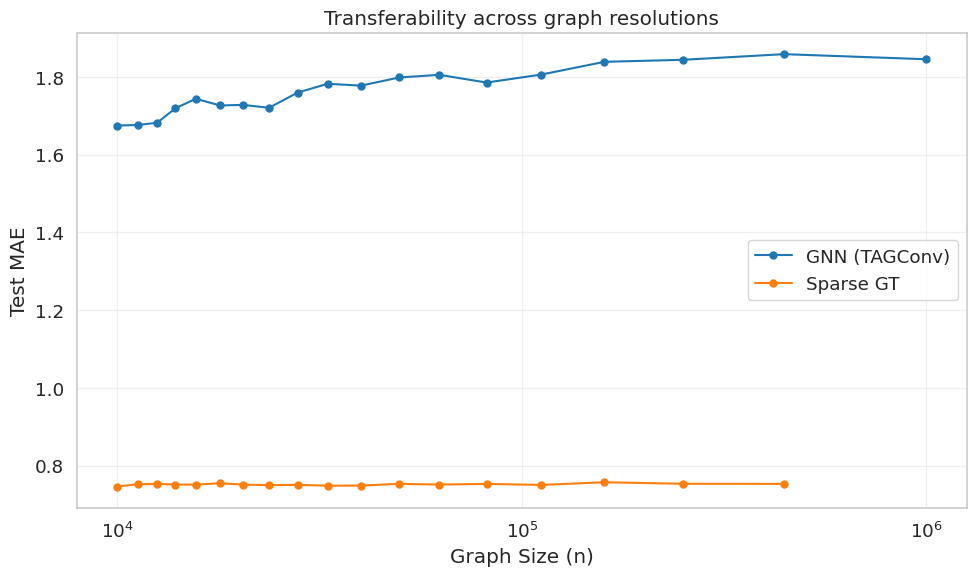

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.2)

LABEL_MAP = {"TAGConv": "GNN (TAGConv)", "SparseGT": "Sparse GT"}
COLOR_MAP = {"GNN (TAGConv)": "#1f77b4", "Sparse GT": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(10, 6))

for layer in ["TAGConv", "SparseGT"]:
    label = LABEL_MAP[layer]
    data = best_per_resolution[
        best_per_resolution["layer_type"] == layer
    ].sort_values("num_nodes")

    if data.empty:
        continue

    ax.plot(
        data["num_nodes"], data[ERROR_COL],
        marker="o", label=label, color=COLOR_MAP[label],
        linewidth=1.5, markersize=5,
    )

ax.set_xscale("log")
ax.set_xlabel("Graph Size (n)")
ax.set_ylabel(ERROR_LABEL)
ax.set_title("Transferability across graph resolutions")
ax.legend(loc="center right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

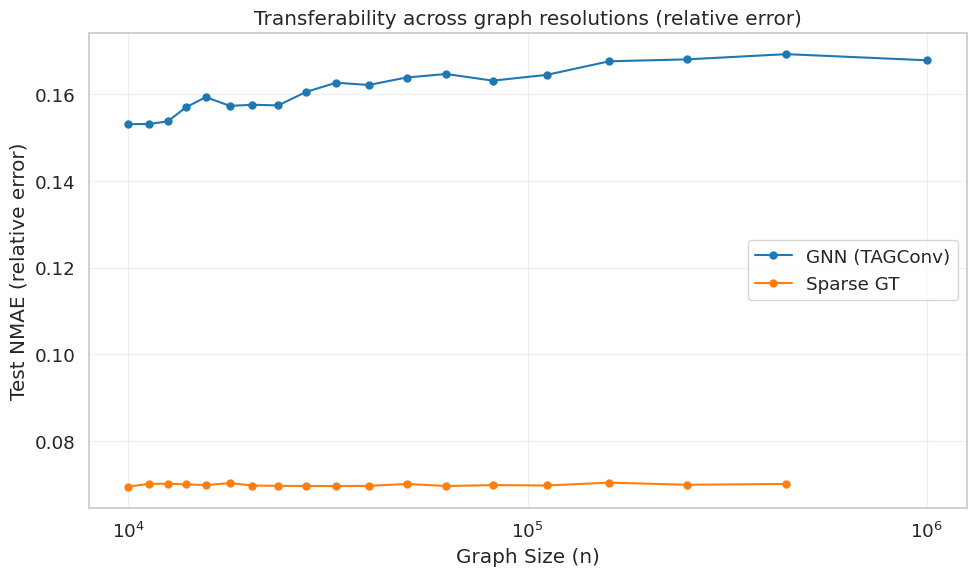

In [ ]:
# Transferability plot in relative error (NMAE)
sns.set_theme(style="whitegrid", font_scale=1.2)

LABEL_MAP = {"TAGConv": "GNN (TAGConv)", "SparseGT": "Sparse GT"}
COLOR_MAP = {"GNN (TAGConv)": "#1f77b4", "Sparse GT": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(10, 6))

for layer in ["TAGConv", "SparseGT"]:
    label = LABEL_MAP[layer]
    data = best_per_resolution_nmae[
        best_per_resolution_nmae["layer_type"] == layer
    ].sort_values("num_nodes")

    if data.empty:
        continue

    ax.plot(
        data["num_nodes"], data["test_nmae"],
        marker="o", label=label, color=COLOR_MAP[label],
        linewidth=1.5, markersize=5,
    )

ax.set_xscale("log")
ax.set_xlabel("Graph Size (n)")
ax.set_ylabel("Test NMAE (relative error)")
ax.set_title("Transferability across graph resolutions (relative error)")
ax.legend(loc="center right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Training curves (loss over epochs)

Fetching loss curves: 100%|██████████| 6/6 [00:04<00:00,  1.43it/s]


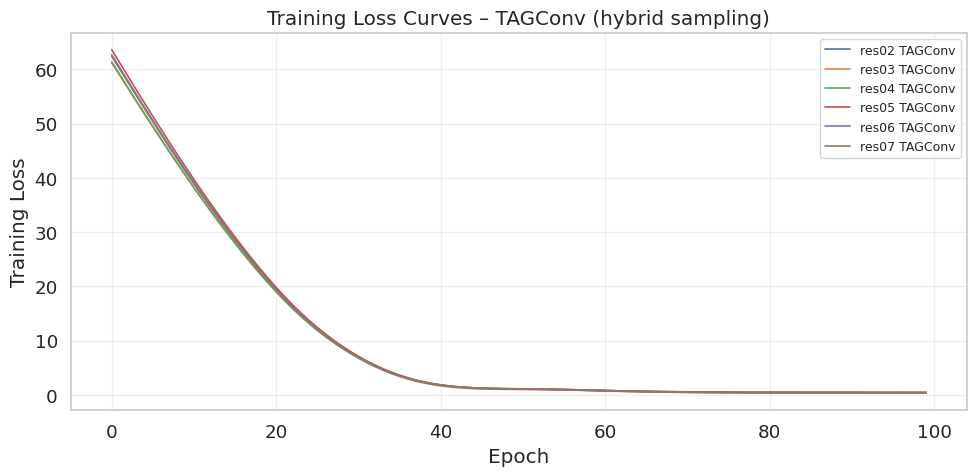

In [ ]:
def fetch_loss_curves(df, entity, project, metric="train_loss", max_runs=6):
    api = wandb.Api()
    curves = {}
    subset = df.head(max_runs)
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Fetching loss curves"):
        run = api.run(f"{entity}/{project}/{row['id']}")
        history = run.history(keys=[metric, "epoch"], pandas=True)
        if not history.empty and metric in history.columns:
            label = f"res{row['resolution']:02d} {row['layer_type']}"
            curves[label] = history[["epoch", metric]].dropna()
    return curves

tagconv_runs = df[
    (df["layer_type"] == "TAGConv") & df["test_mae"].notna()
].sort_values("resolution")

curves = fetch_loss_curves(tagconv_runs, ENTITY, PROJECT, metric="train_loss", max_runs=6)

if curves:
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, hist in curves.items():
        ax.plot(hist["epoch"], hist["train_loss"], label=label, linewidth=1.2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss Curves – TAGConv (hybrid sampling)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No training loss curves available.")

---
## Error distribution by resolution

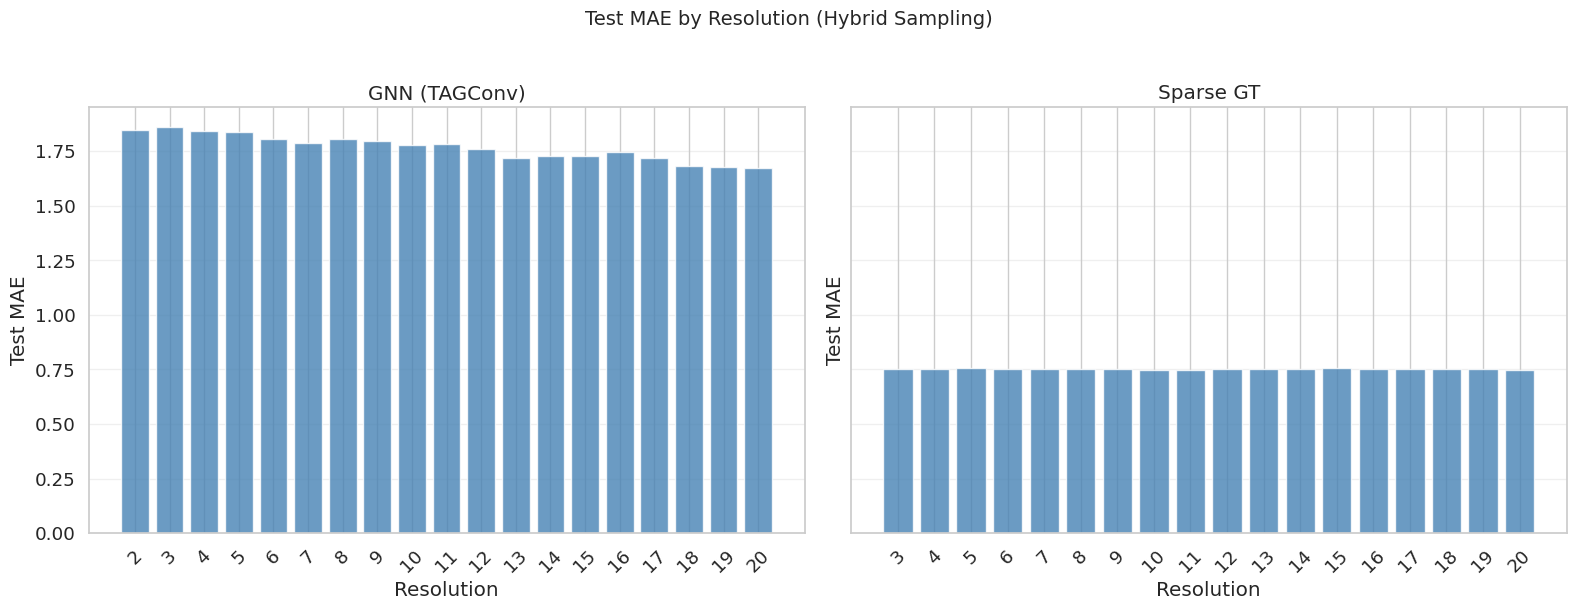

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, layer in zip(axes, ["TAGConv", "SparseGT"]):
    label = LABEL_MAP[layer]
    sub = best_per_resolution[
        best_per_resolution["layer_type"] == layer
    ].sort_values("resolution")

    if sub.empty:
        ax.set_title(f"{label}: no data")
        continue

    ax.bar(sub["resolution"].astype(str), sub["test_mae"], color="steelblue", alpha=0.8)
    ax.set_xlabel("Resolution")
    ax.set_ylabel(ERROR_LABEL)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Test MAE by Resolution (Hybrid Sampling)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Run status summary

In [ ]:
print("=== e25 Hybrid Sampling Run Summary ===")
print(f"Total runs: {len(df)}")
print(f"\nBy state:")
print(df["state"].value_counts().to_string())
print(f"\nBy layer_type:")
print(df["layer_type"].value_counts().to_string())
print(f"\nResolutions covered: {sorted(df['resolution'].unique())}")
print(f"\nExpected resolutions (2–20): {list(range(2, 21))}")
missing = set(range(2, 21)) - set(df["resolution"].unique())
if missing:
    print(f"Missing resolutions (2–20): {sorted(missing)}")
else:
    print("All resolutions (2–20) present.")

=== e25 Hybrid Sampling Run Summary ===
Total runs: 37

By state:
state
finished    37

By layer_type:
layer_type
TAGConv     19
SparseGT    18

Resolutions covered: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Expected resolutions (2–20): [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
All resolutions (2–20) present.
